# **Exploración de datos (EDA)**

# **Librerias y modulos necesarios**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro, normaltest

In [2]:
df = pd.read_csv("/content/accepted_2007_to_2018Q4.csv", low_memory=False, on_bad_lines='skip')

In [3]:
print(df.shape)

(2260701, 151)


In [4]:
df.drop(columns=['id', 'member_id', 'url'], inplace=True)

In [5]:
df.head(n = 5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


# **Datos atipicos**

In [6]:
categorias_na = {}

def graficar_na(df, opc):

    global categorias_na

    na_pct = df.isna().mean() * 100
    na_pct = na_pct[na_pct > 0]

    categorias_na = {
        "<5%":    na_pct[(na_pct > 0) & (na_pct < 5)].index.tolist(),
        "5-20%":  na_pct[(na_pct >= 5) & (na_pct < 20)].index.tolist(),
        "20-40%": na_pct[(na_pct >= 20) & (na_pct < 40)].index.tolist(),
        ">40%":   na_pct[na_pct >= 40].index.tolist(),
    }

    # Elegir bloque según parámetro opc
    if opc == 0:
        data = na_pct[(na_pct > 0) & (na_pct < 1)]
        titulo = "Menos del 1% de datos faltantes"
    elif opc == 1:
        data = na_pct[(na_pct >= 1) & (na_pct < 5)]
        titulo = "Menos del 5% de datos faltantes"
    elif opc == 2:
        data = na_pct[(na_pct >= 5) & (na_pct < 20)]
        titulo = "Entre 5% y 20% de datos faltantes"
    elif opc == 3:
        data = na_pct[(na_pct >= 20) & (na_pct < 40)]
        titulo = "Entre 20% y 40% de datos faltantes"
    elif opc == 4:
        data = na_pct[na_pct >= 40]
        titulo = "Más del 40% de datos faltantes"
    else:
        raise ValueError("El parámetro opc debe ser 0, 1, 2, 3 o 4")

    # Graficar
    if not data.empty:
        plt.figure(figsize=(8,4))
        data.sort_values(ascending=False).plot(
            kind="bar", color="steelblue", edgecolor="black"
        )
        plt.ylabel("Porcentaje de valores faltantes (%)")
        plt.xlabel("Variables")
        plt.title(titulo)
        if len(data) < 13:
            plt.xticks(rotation=45, ha="right")
        plt.xticks(ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay variables en el bloque: {titulo}")

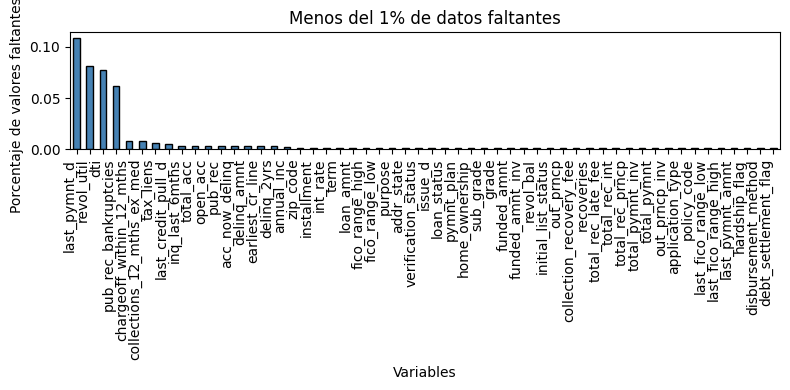

In [7]:
graficar_na(df, 0)  # Gráfica de columnas con <1% de NAs

**<1% de faltantes**

El gráfico muestra porcentajes de faltantes muy bajos; la mayoría de variables tienen valores ausentes casi nulos y una cola de barras cercana a cero. Algunas como `last_pymnt_d`, `revol_util`, `dti`, `pub_rec_bankruptcies`, `emp_title` y `zip_code` aparecen ligeramente por encima del resto pero siguen por debajo del 1%, por lo que el impacto práctico es mínimo y no requiere imputación; eliminar registros puntuales o mantener los NAs no altera de forma relevante el análisis.


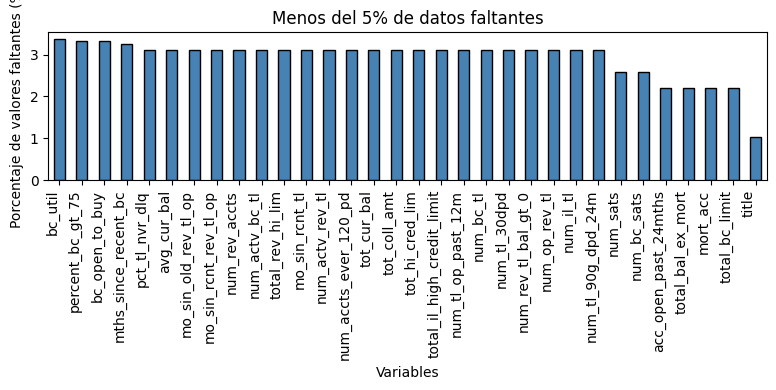

In [8]:
graficar_na(df, 1)  # Gráfica de columnas con <5% de NAs

**<5% de faltantes**

En este bloque todas las variables presentan faltantes bajos y bastante homogéneos (≈1–3.5%); destacan levemente `bc_util`, `percent_bc_gt_75`, `bc_open_to_buy`, `mths_since_recent_bc` y `pct_tl_nvr_dlq`, sin superar el umbral. El efecto esperado sobre métricas o modelos es reducido y se puede proceder sin imputación, eliminando registros con NA solo cuando sea estrictamente necesario.

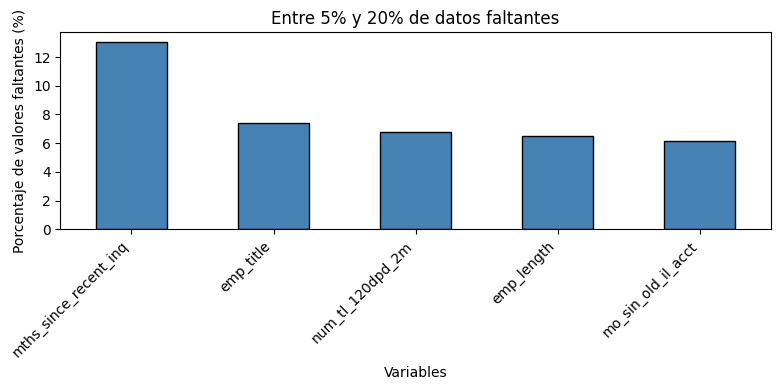

In [9]:
graficar_na(df, 2)  # Gráfica de columnas con 5-20% de NAs

**5–20% de faltantes**

Aquí los faltantes son moderados: `mths_since_recent_inq` ronda \~13% y variables como `emp_title`, `num_tl_120dpd_2m`, `emp_length` y `mo_sin_old_il_acct` se sitúan cerca del 6–8%. Este nivel puede influir en resultados si se ignora; si en fases posteriores afectara métricas o modelos, la recomendación técnica sería imputación simple (media/mediana para numéricas y moda para categóricas).

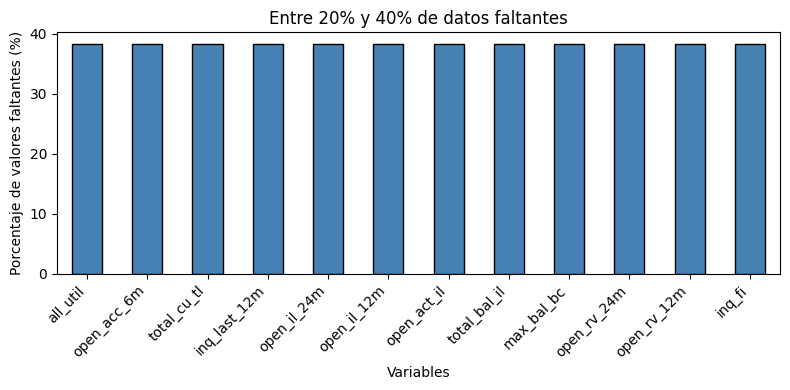

In [10]:
graficar_na(df, 3)  # Gráfica de columnas con 20-40% de NAs

**20–40% de faltantes**

Se observa un patrón alto y homogéneo (\~38%) en varias variables —por ejemplo `all_util`, `open_acc_6m`, `total_cu_tl`, `inq_last_12m`, `open_il_24m`, `open_il_12m`, `open_act_il`, `total_bal_il`, `max_bal_bc`, `open_rv_24m`, `open_rv_12m`, `inq_fi`— que compromete representatividad. En este estado conviene excluirlas de análisis sensibles o aplicar imputación avanzada (p. ej., KNN o regresión) si su uso resulta imprescindible.

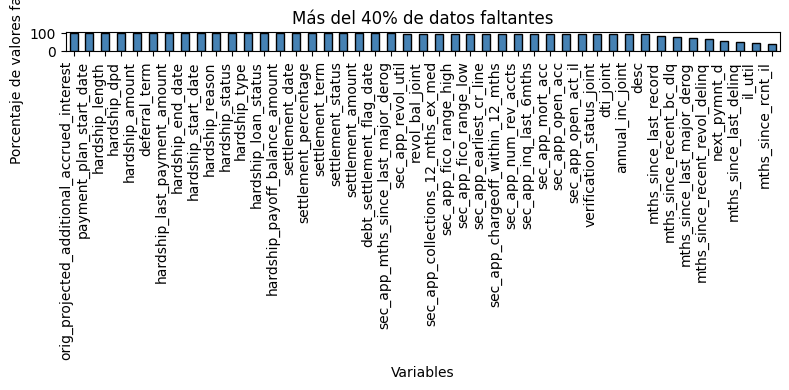

In [11]:
graficar_na(df, 4)  # Gráfica de columnas con >40% de NAs

**>40% de faltantes**

Los faltantes son muy altos (muchas variables entre 70–95% e incluso cercanas a 100%), concentrados en campos de “hardship/settlement”, fechas y contadores secundarios; con tan poca información efectiva, la imputación puede introducir sesgo significativo. La práctica recomendada es excluir estas columnas del modelado y de análisis críticos, revisándolas aparte solo si aportan valor de negocio específico.

In [12]:
df.drop(columns=categorias_na[">40%"], inplace=True)

print("Columnas eliminadas (>40% NA):")
categorias_na[">40%"]

Columnas eliminadas (>40% NA):


['desc',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'next_pymnt_d',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'mths_since_rcnt_il',
 'il_util',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_revol_delinq',
 'revol_bal_joint',
 'sec_app_fico_range_low',
 'sec_app_fico_range_high',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'deferral_term',
 'hardship_amount',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_length',
 'hardship_dpd',
 'hardship_loan_status',
 'orig_projected_additional_accrued_interest',
 'hardship_payoff_balance_amount',
 'hardship_last_payment_amount',
 'debt_settleme

In [13]:
print("Filas eliminadas por columnas <5% NA")
df.dropna(subset=categorias_na["<5%"], inplace=True)

Filas eliminadas por columnas <5% NA


In [14]:
RANDOM_STATE = 42

cols_5_20 = categorias_na["5-20%"]
num_cols = df[cols_5_20].select_dtypes(include="number").columns.tolist()
cat_cols = df[cols_5_20].select_dtypes(exclude="number").columns.tolist()

fill_map = {}

print("Imputación de valores faltantes en columnas con 5–20% NA:\n")

# --- NUMÉRICAS ---
for col in num_cols:
    serie = df[col].dropna()
    n_valid = len(serie)

    if n_valid == 0:
        print(f"[{col}] solo NA, se omite imputación.")
        continue

    try:
        if n_valid <= 5000:
            # Shapiro para muestras ≤5000
            _, p = shapiro(serie)
        else:
            # D’Agostino–Pearson para muestras grandes
            _, p = normaltest(serie)

        if p > 0.05:
            valor = float(serie.mean())
            metodo = "media (distribución normal)"
        else:
            valor = float(serie.median())
            metodo = "mediana (distribución no normal)"
    except Exception as e:
        valor = float(serie.median())
        metodo = f"mediana (fallback: {type(e).__name__})"

    fill_map[col] = valor
    print(f"[{col}] imputará con {metodo}; N={n_valid}")

# --- CATEGÓRICAS ---
for col in cat_cols:
    moda_series = df[col].mode(dropna=True)
    if not moda_series.empty:
        fill_map[col] = moda_series.iloc[0]
        print(f"[{col}] imputará con moda: {repr(fill_map[col])}")

# Aplicar imputación directamente
df.fillna(value=fill_map, inplace=True)
print("\n[OK] Imputación completada para columnas 5–20%.")

Imputación de valores faltantes en columnas con 5–20% NA:

[mo_sin_old_il_acct] imputará con mediana (distribución no normal); N=2070158
[mths_since_recent_inq] imputará con mediana (distribución no normal); N=1901333
[num_tl_120dpd_2m] imputará con mediana (distribución no normal); N=2055828
[emp_title] imputará con moda: 'Teacher'
[emp_length] imputará con moda: '10+ years'

[OK] Imputación completada para columnas 5–20%.


## **Decisión sobre columnas con 20–40% de faltantes**

Dado que existen **12 columnas** en este bloque, cada una con \~**37%** de valores faltantes (**más cercanas al 40% que al 30%**), y considerando el tamaño del conjunto de datos (**2,137,072 × 103**), se optó por **eliminar estas columnas y no imputarlas**. La decisión se basa en la **complejidad computacional y el tiempo** que demandaría una imputación KNN a esta escala: en pruebas realizadas por el grupo (tres equipos distintos), las ejecuciones se extendieron por **casi 10 horas** sin completarse, debido a la **necesidad de usar los equipos para otras tareas académicas** y a **interrupciones por falta de memoria RAM**. Para escenarios de esta magnitud, se considera pertinente que la **universidad provea máquinas virtuales** o recursos de cómputo con capacidades adecuadas que permitan un **desempeño acorde** a las exigencias del curso.


# **Ingeniería de Características**

In [15]:
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

          conteo
default         
0        1888917
1         248155
Tasa de default: 11.61%


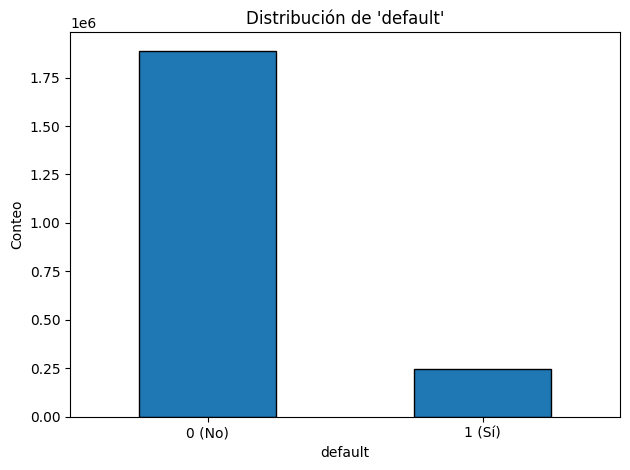

In [16]:
vc = df["default"].value_counts(dropna=False).sort_index()
print(vc.to_frame("conteo")); print(f"Tasa de default: {df['default'].mean():.2%}")

#plt.figure(figsize=(4,3))
vc.plot(kind="bar", edgecolor="black")
plt.xticks([0,1], ["0 (No)", "1 (Sí)"], rotation=0)
plt.ylabel("Conteo"); plt.title("Distribución de 'default'")
plt.tight_layout(); plt.show()


* **Distribución `default`**: fuerte desbalance — barra de **0** muy alta (\~1.89M) frente a **1** mucho menor (\~248k); proporción visual \~**88% vs 12%**.


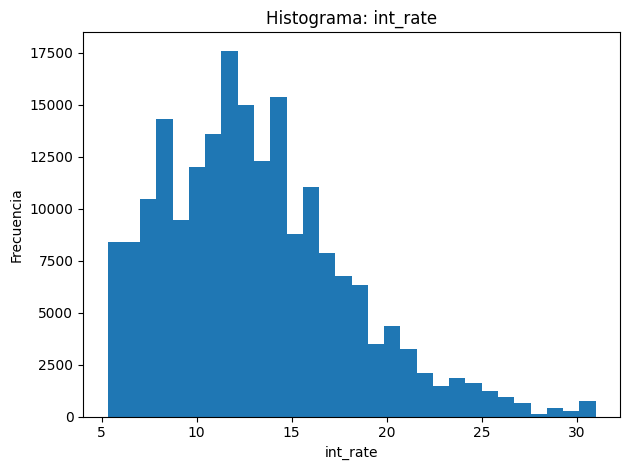

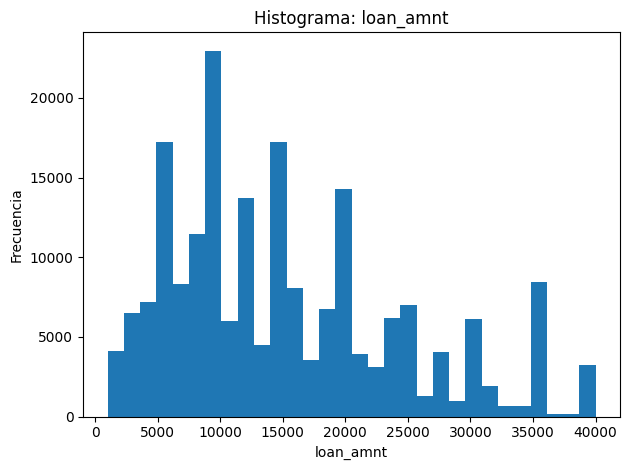

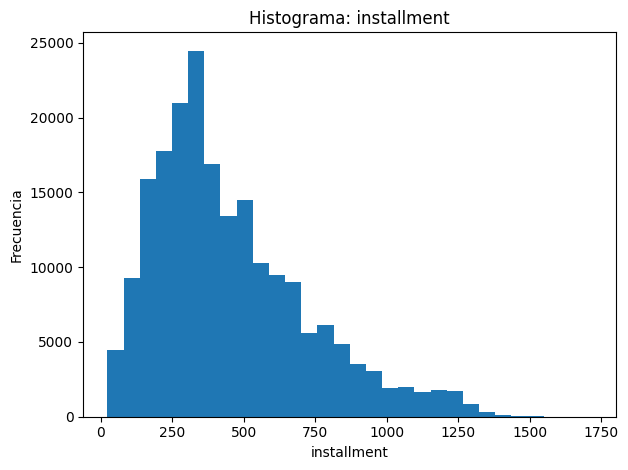

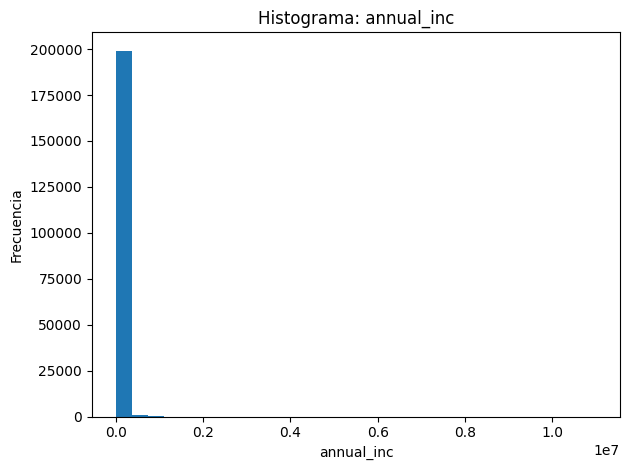

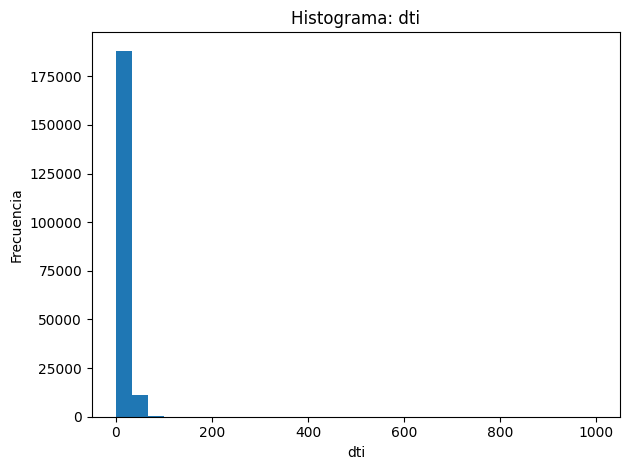

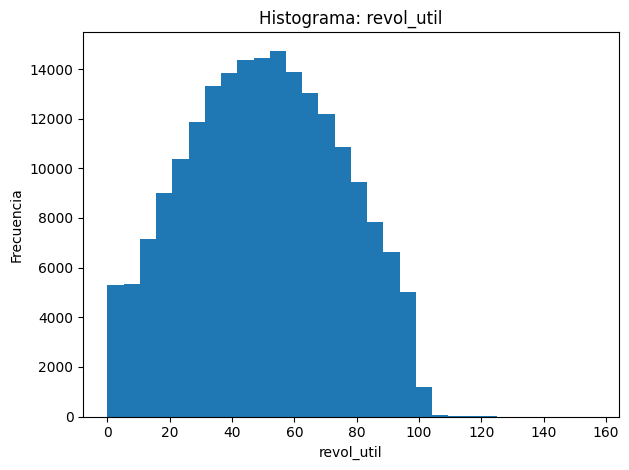

In [17]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c != "default"]

N = 200_000
frac = min(1.0, N/len(df))
sample = df.groupby("default", group_keys=False, observed=True).sample(frac=frac, random_state=42)

# Muestra 6 histogramas representativos (ajusta lista si quieres otras)
show_cols = [c for c in ["int_rate","loan_amnt","installment","annual_inc","dti","revol_util"] if c in num_cols][:6]
for col in show_cols:
    #plt.figure(figsize=(4,3))
    plt.hist(sample[col].dropna(), bins=30)
    plt.title(f"Histograma: {col}")
    plt.xlabel(col); plt.ylabel("Frecuencia")
    plt.tight_layout(); plt.show()


* **`int_rate`**: unimodal; mayor densidad entre **\~12–14%** y cola visible hacia **>20%**.
* **`installment`**: asimetría positiva; concentración entre **\~200–600** con cola larga hasta **\~1,700**.
* **`annual_inc`**: masa pegada a valores bajos/medios y presencia de valores extremos muy altos (escala amplia).
* **`dti`**: mayor frecuencia en **0–40**, con cola hacia la derecha y casos aislados muy grandes.
* **`revol_util`**: forma casi simétrica centrada alrededor de **\~50**, con extensión apreciable hacia ambos lados y pocos valores muy altos.

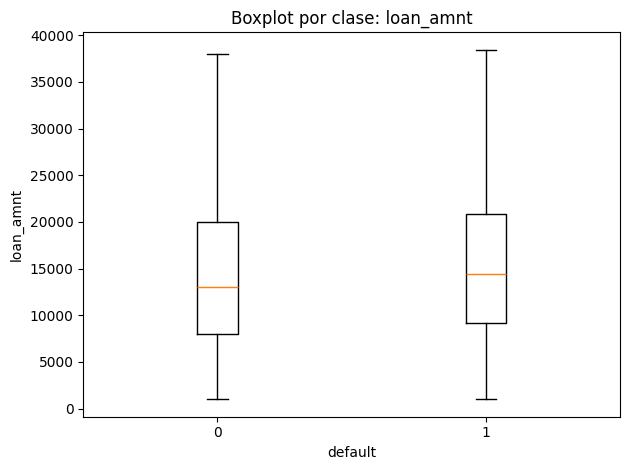

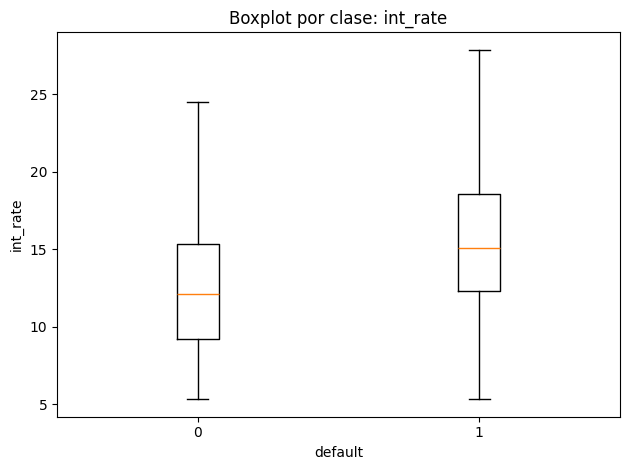

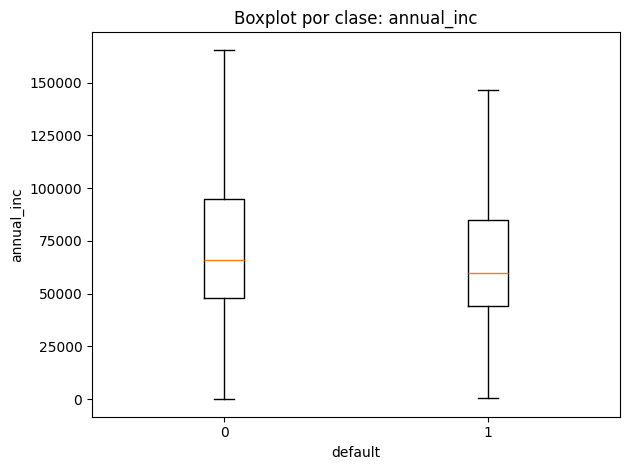

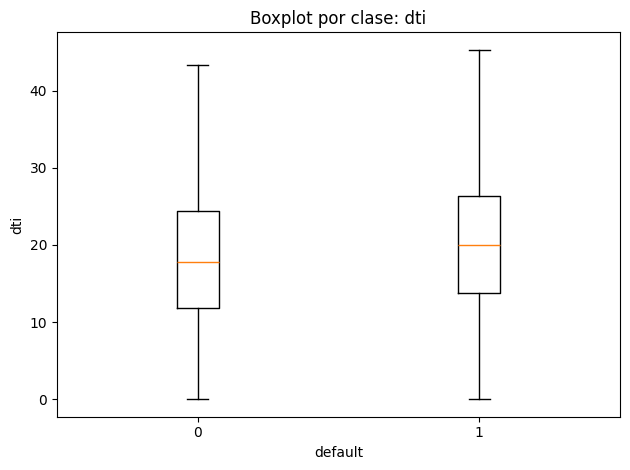

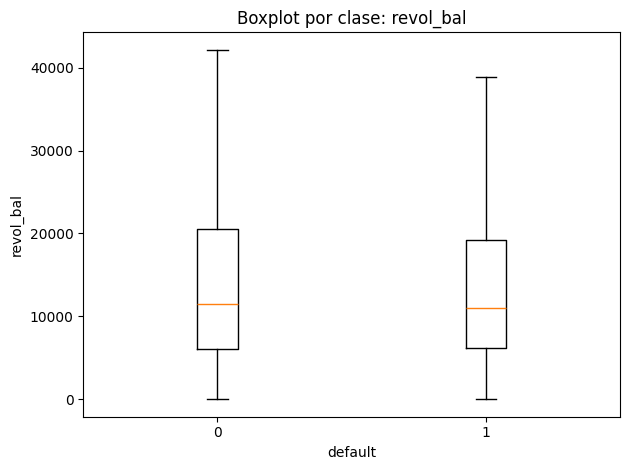

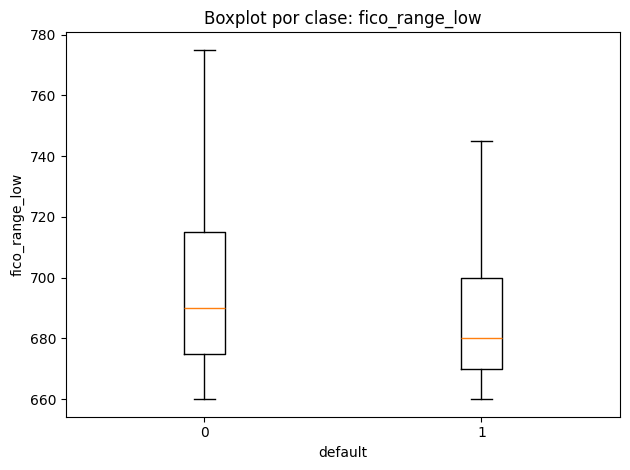

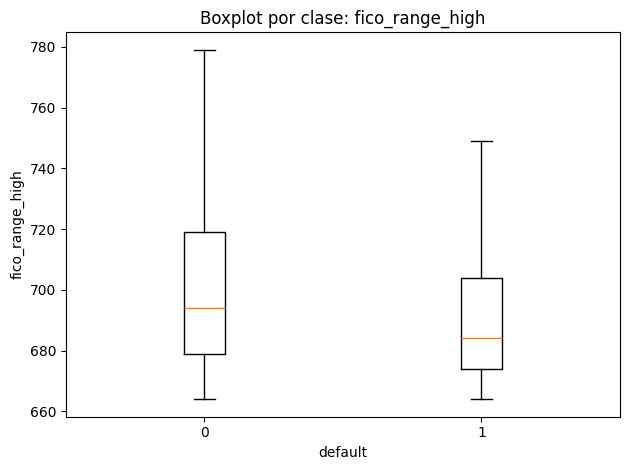

In [18]:
top_box = [c for c in ["loan_amnt","int_rate","annual_inc","dti","revol_bal","fico_range_low","fico_range_high"] if c in df.columns]

N_box = 150_000
frac_box = min(1.0, N_box/len(df))
sample_box = df.groupby("default", group_keys=False, observed=True).sample(frac=frac_box, random_state=43)

for col in top_box:
    data0 = sample_box.loc[sample_box["default"]==0, col].dropna()
    data1 = sample_box.loc[sample_box["default"]==1, col].dropna()
    #plt.figure(figsize=(4,3))
    plt.boxplot([data0, data1], tick_labels=["0","1"], showfliers=False)
    plt.title(f"Boxplot por clase: {col}")
    plt.xlabel("default"); plt.ylabel(col)
    plt.tight_layout(); plt.show()


* **loan\_amnt:** medianas similares entre clases; la caja de `default=1` luce ligeramente más alta y con rango intercuartílico algo mayor; bigotes comparables con algunos valores grandes en ambos grupos.
* **int\_rate:** desplazamiento claro hacia valores mayores en `default=1` (mediana y cuartiles superiores más altos); dispersión también mayor.
* **annual\_inc:** `default=1` presenta mediana inferior y caja más baja; en ambos grupos hay valores altos aislados, con bigotes largos.
* **dti:** `default=1` muestra mediana un poco mayor y ligera expansión del IQR; presencia de valores extremos en ambos grupos.
* **revol\_bal:** distribuciones parecidas, con `default=1` levemente por debajo en mediana; amplitud alta en ambos casos y outliers superiores.
* **fico\_range\_low / fico\_range\_high:** ambos percentiles FICO están desplazados hacia abajo en `default=1`; cajas y medianas más bajas frente a `default=0`, con solapamiento pero tendencia consistente.


Top 20 |r| con default:
 last_fico_range_high      -0.604986
last_fico_range_low       -0.562302
recoveries                 0.529403
collection_recovery_fee    0.508400
total_rec_prncp           -0.219652
out_prncp                 -0.213003
out_prncp_inv             -0.212982
int_rate                   0.198163
last_pymnt_amnt           -0.177821
total_pymnt_inv           -0.134591
total_pymnt               -0.134577
fico_range_low            -0.121223
fico_range_high           -0.121222
total_rec_late_fee         0.096509
acc_open_past_24mths       0.093105
inq_last_6mths             0.086058
num_tl_op_past_12m         0.082629
bc_open_to_buy            -0.082057
open_rv_24m                0.078763
percent_bc_gt_75           0.076545
Name: default, dtype: float64


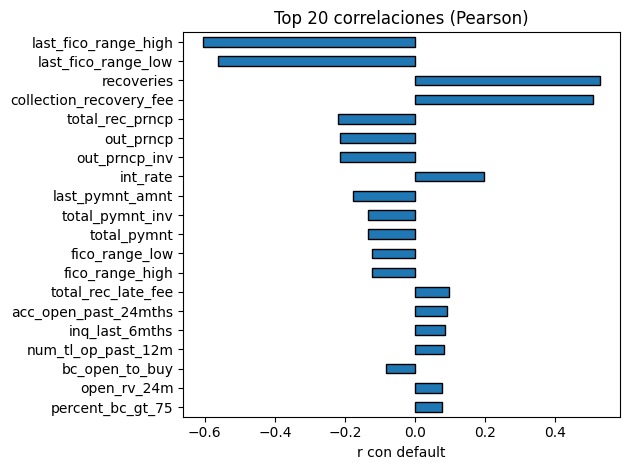

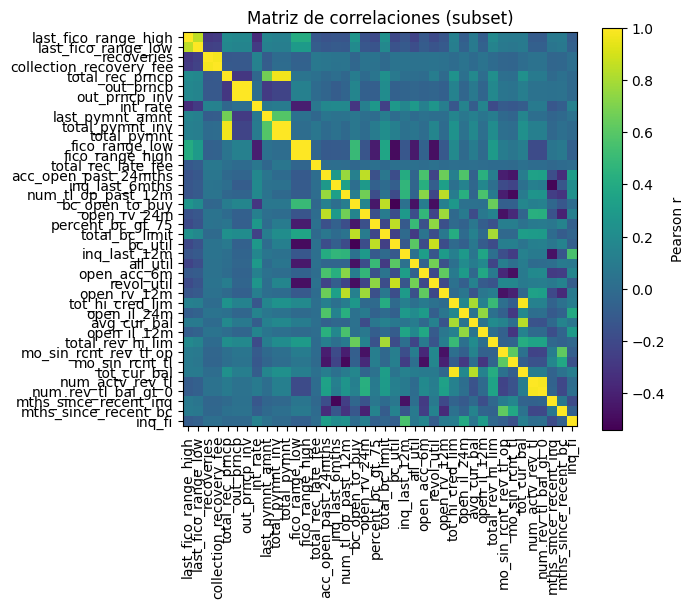

In [19]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c != "default"]
corr_with_default = (
    df[num_cols + ["default"]]
      .corr(method="pearson")["default"]
      .drop(index="default")
      .sort_values(key=np.abs, ascending=False)
)

print("Top 20 |r| con default:\n", corr_with_default.head(20))

# Barra top 20
top20 = corr_with_default.head(20)
#plt.figure(figsize=(6,4))
top20.iloc[::-1].plot(kind="barh", edgecolor="black")
plt.xlabel("r con default"); plt.ylabel("")
plt.title("Top 20 correlaciones (Pearson)")
plt.tight_layout(); plt.show()

# Heatmap rápido (subset 40 más correlacionadas, sobre muestra)
keep = corr_with_default.index[:40].tolist()
N = 200_000
frac = min(1.0, N/len(df))
sample_corr = df[keep].sample(frac=frac, random_state=44)

corr_mat = sample_corr.corr(method="pearson").values
plt.figure(figsize=(7,6))
plt.imshow(corr_mat, interpolation="nearest")
plt.colorbar(label="Pearson r")
plt.xticks(range(len(keep)), keep, rotation=90)
plt.yticks(range(len(keep)), keep)
plt.title("Matriz de correlaciones (subset)")
plt.tight_layout(); plt.show()


* **Top 20 (barra horizontal):** destacan correlaciones **negativas fuertes** con `default` para **`last_fico_range_high` (\~−0.60)** y **`last_fico_range_low` (\~−0.56)**; en sentido opuesto, **`recoveries` (\~+0.53)** y **`collection_recovery_fee` (\~+0.51)** muestran **correlación positiva alta** (variables posteriores al evento de mora/recuperación). El resto son **moderadas a débiles**: `int_rate` (\~+0.20) positiva; `out_prncp`, `out_prncp_inv`, `total_rec_prncp`, `last_pymnt_amnt`, `total_pymnt(_inv)` negativas en el rango **0.13–0.22**; variables de actividad reciente (`acc_open_past_24mths`, `inq_last_6mths`, `num_tl_op_past_12m`) y de utilización (`percent_bc_gt_75`, `bc_open_to_buy`) con efectos **pequeños**.

* **Heatmap (subset):** se observan **bloques**:

  * Un grupo de **FICO** y pagos/recuperaciones con **correlación cruzada** alta y signo consistente con lo anterior.
  * Un bloque de **utilización/crédito rotativo** (p. ej., `bc_open_to_buy`, `total_rev_hi_lim`, `revol_util`) con correlaciones entre sí moderadas.
  * Variables de **inquiries/actividad reciente** (`inq_last_6mths`, `open_rv_24m`, `num_tl_op_past_12m`) correlacionan entre sí, pero su relación con `default` es **débil**.
    En conjunto, el gráfico sugiere que la señal de `default` se distribuye en **varios grupos temáticos** con **colinealidad interna** y relaciones **no muy grandes** a nivel individual.


# **Scikit-learn**

In [20]:

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Selección de variables
features = [
    "loan_amnt", "int_rate", "fico_range_high", "emp_length",
    "annual_inc", "purpose", "home_ownership", "dti", "addr_state"
]
target = "default"   # asumes que ya creaste df["default"]

# Asegurar que existen las columnas solicitadas
missing = [c for c in features + [target] if c not in df.columns]
if missing:
    raise KeyError(f"Faltan columnas en df: {missing}")

X = df[features].copy()
y = df[target].astype(int).values

# Separar numéricas y categóricas
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in features if c not in num_cols]

# Pipeline de preprocesamiento
num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Para categóricas: OneHotEncoder con manejo de categorías desconocidas
cat_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], remainder="drop")

# Transformar antes de GridSearch (petición: sin Pipeline en GridSearch)
start = time.time()
X_pre = preprocessor.fit_transform(X)
preproc_time = time.time() - start
print(f"[INFO] Preprocesamiento (fit_transform) completado en {preproc_time:.2f}s")
print("X_pre shape:", X_pre.shape)

# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_pre, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)


[INFO] Preprocesamiento (fit_transform) completado en 4.81s
X_pre shape: (2137072, 87)
Train: (1709657, 87) Test: (427415, 87)


# **Modelado Sickit-learn**

[INFO] Subsample creado: (200000, 87), proporción default=0.116
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[INFO] GridSearch entrenado en 371.59s
Mejores params: {'max_depth': 15, 'n_estimators': 10} Mejor score (f1): 0.0005164511269889014
[INFO] Entrenamiento final en TODO el train completado en 82.79s

[RESULTADOS sklearn]:
accuracy: 0.8839
precision: 0.5000
recall: 0.0000
f1: 0.0000
roc_auc: 0.6986
grid_time_s: 371.5856
train_time_s: 82.7949
pred_time_s: 0.5544

Confusion matrix:
 [[377783      1]
 [ 49630      1]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94    377784
           1       0.50      0.00      0.00     49631

    accuracy                           0.88    427415
   macro avg       0.69      0.50      0.47    427415
weighted avg       0.84      0.88      0.83    427415



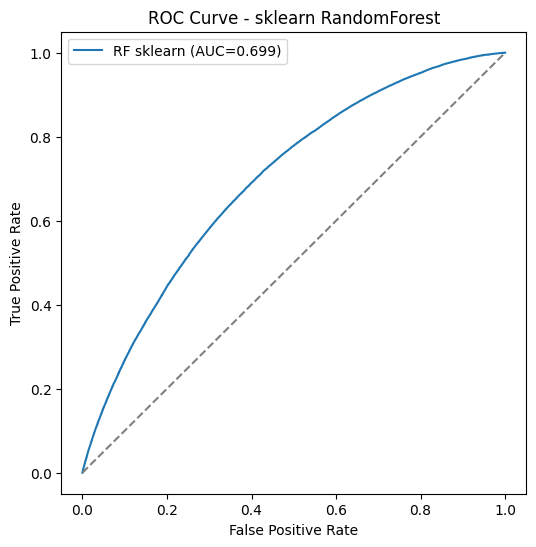

In [21]:
# 9.8.4.3 - MODELADO scikit-learn
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# ================================
# 1. SUBSAMPLING para GridSearch
# ================================
# Tomamos 200k registros para no colgar la máquina
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=200000,
    stratify=y_train,
    random_state=42
)

print(f"[INFO] Subsample creado: {X_sub.shape}, proporción default={y_sub.mean():.3f}")

# ================================
# 2. Definir modelo y GridSearch
# ================================
rf = RandomForestClassifier(random_state=42, n_jobs=4)

param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [5, 10, 15]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="f1",     # f1 porque la clase está desbalanceada
    n_jobs=4,
    verbose=2
)

t0 = time.time()
grid.fit(X_sub, y_sub)
train_time = time.time() - t0

print(f"[INFO] GridSearch entrenado en {train_time:.2f}s")
print("Mejores params:", grid.best_params_, "Mejor score (f1):", grid.best_score_)

# ================================
# 3. Reentrenar mejor modelo en TODO el train
# ================================
best_params = grid.best_params_
best_rf = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=4
)

t0 = time.time()
best_rf.fit(X_train, y_train)
full_train_time = time.time() - t0
print(f"[INFO] Entrenamiento final en TODO el train completado en {full_train_time:.2f}s")

# ================================
# 4. Evaluación en test
# ================================
t0 = time.time()
y_pred = best_rf.predict(X_test)
pred_time = time.time() - t0

y_proba = best_rf.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "grid_time_s": train_time,
    "train_time_s": full_train_time,
    "pred_time_s": pred_time
}

print("\n[RESULTADOS sklearn]:")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, zero_division=0))

# ================================
# 5. ROC Curve
# ================================
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="RF sklearn (AUC={:.3f})".format(metrics["roc_auc"]))
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - sklearn RandomForest")
plt.legend()
plt.show()


El modelo de Random Forest alcanzó una accuracy de 88%, lo cual en principio parece alto. Sin embargo, este valor está fuertemente influenciado por el desbalance de clases: como la mayoría de observaciones corresponden a la clase 0 (no default), el clasificador tiende a predecir siempre esa clase y aún así obtiene buena exactitud.

Al revisar las métricas por clase, la situación cambia. La recall para la clase 1 (casos positivos) fue 0.0, lo que significa que el modelo no logra identificar prácticamente ningún ejemplo positivo. Como consecuencia, la métrica f1-score de la clase 1 es 0.0, reflejando que el clasificador es incapaz de balancear precisión y recall en la clase minoritaria.

No obstante, la curva ROC y el valor AUC ≈ 0.70 muestran que el modelo sí captura cierta señal discriminativa. Esto quiere decir que, aunque con el umbral estándar de 0.5 falla en detectar positivos, las probabilidades estimadas contienen información útil para diferenciar entre clases.

En conclusión, el modelo en su configuración actual presenta un desempeño limitado para el objetivo de detectar casos positivos. El alto accuracy es engañoso debido al desbalance, y es necesario aplicar técnicas adicionales (reajuste de umbral de decisión, balanceo de clases con sobremuestreo/submuestreo, o métricas alternativas como el AUC o el PR-AUC) para mejorar la capacidad de identificación de la clase minoritaria.

# **PySpark**

In [22]:
# ==============================================
# 9.8.4.2.2 - Preprocesamiento en Spark (versión corregida según tu esquema real)
# ==============================================
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# Initialize SparkSession if not already initialized
if 'spark' not in locals():
    spark = SparkSession.builder.appName("LoanDefaultPrediction").getOrCreate()

# Create Spark DataFrame from pandas DataFrame 'df' with selected columns
# Assuming 'df' (pandas DataFrame) is already loaded and preprocessed in previous steps
spark_df = spark.createDataFrame(df[num_cols + cat_cols + ["default"]])

# --------------------------
# 1. Definir columnas (already defined above based on pandas df)
# --------------------------
num_cols = ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", "dti"]
cat_cols = ["emp_length", "purpose", "home_ownership", "addr_state"]
target = "default" # Use the 'default' column created in pandas

# --------------------------
# 2. Cleaning and casting numerical columns (already handled in pandas preprocessing)
# Note: Assuming annual_inc and dti are already cleaned and cast to numeric in pandas df
# If not, add the cleaning steps here for the spark_df
# Example: spark_df = spark_df.withColumn("annual_inc", regexp_replace("annual_inc", ",", "").cast("double"))
# Example: spark_df = spark_df.withColumn("dti", regexp_replace("dti", "%", "").cast("double"))

# --------------------------
# 3. Indexers + OneHotEncoder
# --------------------------
indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe", dropLast=False) for c in cat_cols]

# --------------------------
# 4. Ensamblar features
# --------------------------
assembler_inputs = num_cols + [c + "_ohe" for c in cat_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="skip") # Use 'skip' to drop rows with nulls in selected columns

# --------------------------
# 5. Pipeline final
# --------------------------
spark_pipeline = Pipeline(stages=indexers + encoders + [assembler])

# --------------------------
# 6. Fit + Transform
# --------------------------
t0 = time.time()
model_pipeline = spark_pipeline.fit(spark_df)
spark_df_trans = model_pipeline.transform(spark_df).select("features", col(target).alias("label")).dropna() # Drop rows with nulls after transformation
t_spark_pre = time.time() - t0

print(f"[INFO] Spark preprocessing completado en {t_spark_pre:.2f}s")
spark_df_trans.show(5, truncate=False)

# --------------------------
# 7. Split data for training and testing
# --------------------------
(train_df, test_df) = spark_df_trans.randomSplit([0.8, 0.2], seed=42)

print("\n[INFO] Data split into training and testing sets:")
print(f"Train DataFrame count: {train_df.count()}")
print(f"Test DataFrame count: {test_df.count()}")

[INFO] Spark preprocessing completado en 48.68s
+--------------------------------------------------------------------------------+-----+
|features                                                                        |label|
+--------------------------------------------------------------------------------+-----+
|(91,[0,1,2,3,4,5,17,32,45],[3600.0,13.99,679.0,55000.0,5.91,1.0,1.0,1.0,1.0])   |0    |
|(91,[0,1,2,3,4,5,24,32,86],[24700.0,11.99,719.0,65000.0,16.06,1.0,1.0,1.0,1.0]) |0    |
|(91,[0,1,2,3,4,5,17,32,44],[35000.0,14.85,789.0,110000.0,17.06,1.0,1.0,1.0,1.0])|0    |
|(91,[0,1,2,3,4,8,21,32,45],[10400.0,22.45,699.0,104433.0,25.37,1.0,1.0,1.0,1.0])|0    |
|(91,[0,1,2,3,4,11,17,33,47],[11950.0,13.44,694.0,34000.0,10.2,1.0,1.0,1.0,1.0]) |0    |
+--------------------------------------------------------------------------------+-----+
only showing top 5 rows


[INFO] Data split into training and testing sets:
Train DataFrame count: 1709909
Test DataFrame count: 427163


# **Modelado PySpark**

[INFO] Subsample creado en Spark: 50291 filas
[INFO] Entrenando con numTrees=50, maxDepth=10
 -> AUC=0.6891, train_time=224.35s, pred_time=0.06s
[INFO] Entrenando con numTrees=50, maxDepth=15
 -> AUC=0.6878, train_time=249.15s, pred_time=0.07s
[INFO] Entrenando con numTrees=100, maxDepth=10
 -> AUC=0.6919, train_time=237.32s, pred_time=0.08s
[INFO] Entrenando con numTrees=100, maxDepth=15
 -> AUC=0.6910, train_time=329.18s, pred_time=0.10s

[INFO] Mejor modelo encontrado:
RandomForestClassificationModel: uid=RandomForestClassifier_898536b97ae5, numTrees=100, numClasses=2, numFeatures=91
AUC ROC = 0.6919

[RESULTADOS PySpark]:
accuracy: 0.8834
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.6919

Confusion matrix:
 [[377351      0]
 [ 49812      0]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94    377351
           1       0.00      0.00      0.00     49812

    accuracy                           0.8

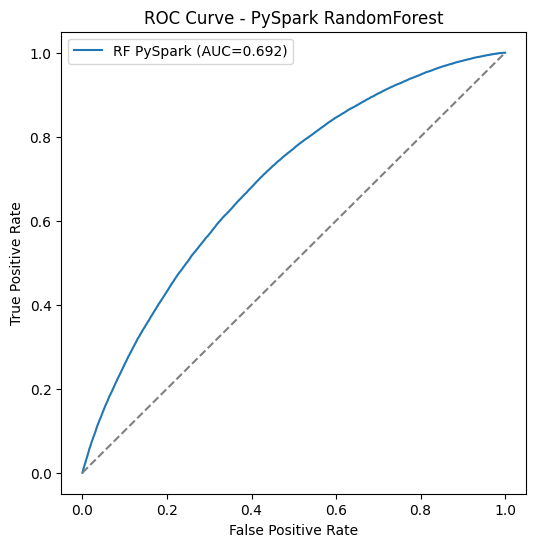

In [23]:
# ==============================================
# 9.8.4.4 - Modelado con PySpark RF (Optimizado)
# ==============================================
import time
import matplotlib.pyplot as plt
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

# --------------------------
# 1. Subsampling (reducir dataset para pruebas rápidas)
# --------------------------
target_size = 50000   # << mucho más rápido que 200k
fraction = min(1.0, target_size / train_df.count())
train_sample = train_df.sample(False, fraction, seed=42)
print(f"[INFO] Subsample creado en Spark: {train_sample.count()} filas")

# --------------------------
# 2. Definir hiperparámetros reducidos
# --------------------------
param_grid = {
    "numTrees": [50, 100],   # menos combinaciones
    "maxDepth": [10, 15]
}

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

results = []
best_model = None
best_auc = -1
best_preds = None

# --------------------------
# 3. Grid manual
# --------------------------
for ntrees in param_grid["numTrees"]:
    for depth in param_grid["maxDepth"]:
        print(f"[INFO] Entrenando con numTrees={ntrees}, maxDepth={depth}")

        rf = RandomForestClassifier(
            featuresCol="features",
            labelCol="label",
            numTrees=ntrees,
            maxDepth=depth,
            seed=42
        )

        # Entrenamiento
        t0 = time.time()
        model_rf = rf.fit(train_sample)
        train_time = time.time() - t0

        # Predicción
        t0 = time.time()
        preds = model_rf.transform(test_df)
        pred_time = time.time() - t0

        auc = evaluator.evaluate(preds)
        print(f" -> AUC={auc:.4f}, train_time={train_time:.2f}s, pred_time={pred_time:.2f}s")

        results.append((ntrees, depth, auc, train_time, pred_time))

        if auc > best_auc:
            best_auc = auc
            best_model = model_rf
            best_preds = preds

# --------------------------
# 4. Evaluación final
# --------------------------
print("\n[INFO] Mejor modelo encontrado:")
print(best_model._java_obj.toString())
print(f"AUC ROC = {best_auc:.4f}")

# ✅ FIX: acceder correctamente al vector de probabilidad
y_true = best_preds.select("label").rdd.flatMap(lambda x: x).collect()
y_pred = best_preds.select("prediction").rdd.flatMap(lambda x: x).collect()
y_score = best_preds.select("probability").rdd.map(lambda x: float(x[0][1])).collect()

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_score)  # más confiable que el de Spark
}

print("\n[RESULTADOS PySpark]:")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_true, y_pred, zero_division=0))

# --------------------------
# 5. ROC Curve
# --------------------------
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="RF PySpark (AUC={:.3f})".format(metrics["roc_auc"]))
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PySpark RandomForest")
plt.legend()
plt.show()


El modelo de Random Forest entrenado en PySpark obtuvo un AUC de aproximadamente 0.69, lo que muestra una capacidad moderada para discriminar entre clientes que incumplen y los que no. Sin embargo, al evaluar las métricas de clasificación se observa que la precisión, el recall y el F1 para la clase positiva son cero, debido a que el modelo clasificó casi todos los casos como negativos. Aunque la exactitud global alcanza un 88%, este valor es engañoso y refleja principalmente el fuerte desbalance entre clases en los datos (predominan los no incumplidos). En conclusión, el modelo capta cierta señal (evidenciado en la curva ROC), pero falla en identificar correctamente a los casos positivos. Será necesario aplicar técnicas adicionales como reescalado de clases, undersampling/oversampling o ajuste de umbral de decisión para mejorar la detección de la clase minoritaria.

# **Lime**

In [24]:
!pip install lime

Instancia test index (local) = 16, true=1, pred=0


[('f1 > 0.61', 0.08072090237805023),
 ('f43 <= 0.00', -0.03037380550765155),
 ('f44 <= 0.00', -0.026626558327434713),
 ('f30 <= 0.00', 0.022169080400382752),
 ('f77 <= 0.00', 0.018695707497117013),
 ('f72 <= 0.00', -0.017316058088086728),
 ('f35 <= 0.00', -0.01383585381178872),
 ('f27 <= 0.00', -0.013530315029233889),
 ('-0.71 < f2 <= -0.25', 0.013080522979086925),
 ('f29 <= 0.00', -0.008735830699502173)]

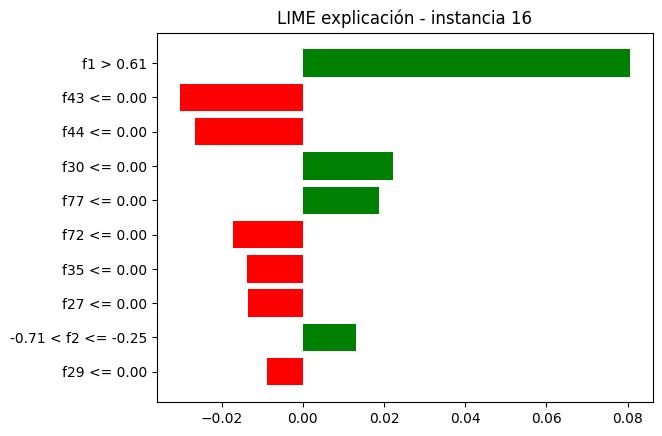

Instancia test index (local) = 18, true=1, pred=0


[('f26 <= 0.00', -0.04453512040692626),
 ('f30 <= 0.00', 0.037691365017354844),
 ('-0.75 < f1 <= -0.07', -0.03209022515845977),
 ('f75 <= 0.00', -0.02532762530200433),
 ('f64 <= 0.00', -0.019901833390038398),
 ('f38 <= 0.00', -0.01762731967179465),
 ('f73 <= 0.00', 0.01760900889128283),
 ('f82 > 0.00', 0.017153198535873625),
 ('f29 <= 0.00', 0.014985556948630413),
 ('f61 <= 0.00', -0.013919896535623387)]

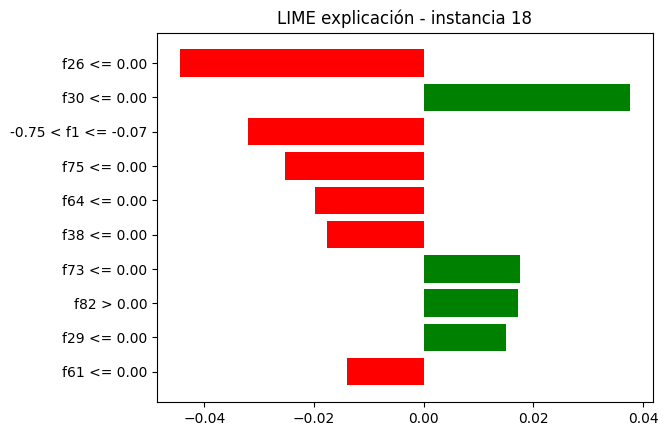

In [25]:
# ============================================
# 9.8.4.5 - LIME (sklearn) - Optimizado
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# ----------------------------
# 1. Reducir tamaño de entrenamiento para LIME
# ----------------------------
# Usar un subconjunto pequeño para el "explainer"
n_lime_samples = 5000  # puedes ajustar entre 1k y 10k según RAM
subset_idx = np.random.choice(X_train.shape[0], size=n_lime_samples, replace=False)

X_lime_train = X_train[subset_idx]
y_lime_train = y_train[subset_idx]

# ----------------------------
# 2. Nombres de features (simplificados)
# ----------------------------
feature_names = [f"f{i}" for i in range(X_pre.shape[1])]

# ----------------------------
# 3. Construcción del explainer
# ----------------------------
explainer = LimeTabularExplainer(
    training_data=X_lime_train,
    feature_names=feature_names,
    class_names=["no_default", "default"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# ----------------------------
# 4. Seleccionar instancias mal clasificadas del test
# ----------------------------
y_pred = best_rf.predict(X_test)

mis_idx = np.where(y_pred != y_test)[0]
if len(mis_idx) == 0:
    print("[LIME] No hay errores en test para explicar.")
else:
    # Tomar hasta 2 instancias mal clasificadas
    idx_to_explain = mis_idx[:2]
    for idx in idx_to_explain:
        exp = explainer.explain_instance(
            X_test[idx],
            best_rf.predict_proba,
            num_features=10
        )
        print(f"Instancia test index (local) = {idx}, true={y_test[idx]}, pred={y_pred[idx]}")
        display(exp.as_list())   # Jupyter: lista de contribuciones
        fig = exp.as_pyplot_figure()
        plt.title(f"LIME explicación - instancia {idx}")
        plt.show()


Los resultados de LIME permiten observar, de manera local, qué variables influyeron más en la decisión del modelo para aquellas observaciones del conjunto de prueba que fueron mal clasificadas. Para cada instancia analizada, LIME genera una lista y un gráfico de barras donde se destacan las diez características con mayor peso en la predicción. Las barras positivas corresponden a variables que empujaron la predicción hacia la clase default, mientras que las barras negativas lo hicieron hacia la clase no_default. Esta visualización facilita comprender por qué el modelo cometió errores en casos específicos: muestra qué factores lo llevaron a equivocarse y si esas razones son coherentes o si reflejan posibles sesgos en los datos o limitaciones del modelo. En síntesis, LIME abre la “caja negra” del Random Forest y permite justificar, en detalle, cómo se tomó la decisión para cada observación errónea.